# F1 Historical Weather Fetcher

Fetches historical weather for every race in `event_location_data.csv` using the **Open-Meteo Archive API** (free, no key required).  
Results are matched to the exact race-start hour (UTC) for each event.

### Weather variables requested
| Variable | Why it matters |
|---|---|
| temperature_2m | Tyre compound choice, engine cooling |
| apparent_temperature | Combined heat/wind feel; driver comfort |
| relative_humidity_2m | Grip loss, condensation risk |
| dew_point_2m | Track condensation threshold (air temp → dew point gap) |
| precipitation | Total water on track (rain + showers + snow) |
| rain | Liquid rain only |
| showers | Convective showers (sudden onset) |
| snowfall | Extreme condition flag |
| weather_code | Weather condition code (clear → thunderstorm) |
| cloud_cover | Track temperature via solar radiation |
| surface_pressure | Air density → downforce level |
| wind_speed_10m | Aerodynamic balance, high-speed corner grip |
| wind_gusts_10m | Sudden handling disruptions |
| wind_direction_10m | Headwind / tailwind on straights |

In [1]:
# Install dependencies (skip if already installed)
%pip install -q requests pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [16]:
import time
import json
import hashlib
from pathlib import Path
from datetime import datetime, timezone

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker
# import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
print("Libraries loaded.")

Libraries loaded.


## Load event data
Previously loaded at ""../data/event_location_data.csv""

In [3]:
events = pd.read_csv("../data/event_location_data.csv", parse_dates=["StartTime"])
events["StartTime"] = pd.to_datetime(events["StartTime"], utc=True)

print(f"Events loaded: {len(events)}  |  Years: {events['Year'].min()}–{events['Year'].max()}")
events.head()

Events loaded: 173  |  Years: 2018–2025


,EventName,Country,Location,StartTime,Year,lon,lat
0,Australian Grand Prix,Australia,Melbourne,2018-03-25 05:10:00+00:00,2018,144.97,-37.85
1,Bahrain Grand Prix,Bahrain,Sakhir,2018-04-08 15:10:00+00:00,2018,50.51,26.03
2,Chinese Grand Prix,China,Shanghai,2018-04-15 06:10:00+00:00,2018,121.22,31.34
3,Azerbaijan Grand Prix,Azerbaijan,Baku,2018-04-29 12:10:00+00:00,2018,49.84,40.37
4,Spanish Grand Prix,Spain,Barcelona,2018-05-13 13:10:00+00:00,2018,2.26,41.57


## Configure weather variables

In [4]:
HOURLY_VARS = [
    "temperature_2m",
    "apparent_temperature",
    "relative_humidity_2m",
    "dew_point_2m",
    "precipitation",
    "rain",
    "showers",
    "snowfall",
    "weather_code",
    "cloud_cover",
    "surface_pressure",
    "wind_speed_10m",
    "wind_gusts_10m",
    "wind_direction_10m",
]

ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"
CACHE_DIR = Path("../data/.weather_cache")
CACHE_DIR.mkdir(exist_ok=True)
print(f"Fetching {len(HOURLY_VARS)} variables per event. Cache: {CACHE_DIR.resolve()}")

Fetching 14 variables per event. Cache: /Users/luisgodoy/Documents/UM-MADS/SIADS 593-Capstone I/mads-f1-analysis/data/.weather_cache


## Fetch function and helpers

In [5]:
# WMO weather code descriptions (https://open-meteo.com/en/docs#weather_variable_documentation)
WMO_DESCRIPTIONS = {
    0: "Clear sky", 1: "Mainly clear", 2: "Partly cloudy", 3: "Overcast",
    45: "Fog", 48: "Depositing rime fog",
    51: "Light drizzle", 53: "Moderate drizzle", 55: "Dense drizzle",
    61: "Slight rain", 63: "Moderate rain", 65: "Heavy rain",
    71: "Slight snow", 73: "Moderate snow", 75: "Heavy snow",
    77: "Snow grains",
    80: "Slight showers", 81: "Moderate showers", 82: "Violent showers",
    85: "Slight snow showers", 86: "Heavy snow showers",
    95: "Thunderstorm", 96: "Thunderstorm w/ slight hail", 99: "Thunderstorm w/ heavy hail",
}


def fetch_hourly_day(lat: float, lon: float, date: str, retries: int = 3) -> dict | None:
    params = {
        "latitude": round(lat, 4),
        "longitude": round(lon, 4),
        "start_date": date,
        "end_date": date,
        "hourly": ",".join(HOURLY_VARS),
        "timezone": "UTC",
    }

    for attempt in range(retries):
        try:
            resp = requests.get(ARCHIVE_URL, params=params, timeout=20)
            if resp.status_code == 200:
                data = resp.json()
                return data
            elif resp.status_code == 429:       # rate limited
                time.sleep(2 ** attempt)
            else:
                print(f"  HTTP {resp.status_code} for {lat},{lon} {date}: {resp.text[:120]}")
                return None
        except requests.RequestException as exc:
            print(f"  Request error attempt {attempt+1}: {exc}")
            time.sleep(1)
    return None


def extract_race_hour(payload: dict, race_hour: int) -> dict:
    hourly = payload.get("hourly", {})
    times = hourly.get("time", [])

    # Find index whose hour matches
    idx = next(
        (i for i, t in enumerate(times) if int(t.split("T")[1].split(":")[0]) == race_hour),
        None,
    )
    if idx is None:
        return {}

    return {var: hourly[var][idx] for var in HOURLY_VARS if var in hourly}

In [6]:
today = pd.Timestamp.now(tz="UTC").normalize()
records = []
skipped = []

for i, row in events.iterrows():
    start_utc: pd.Timestamp = row["StartTime"]
    date_str = start_utc.strftime("%Y-%m-%d")
    race_hour = start_utc.hour

    # Skip events too recent for the archive
    if pd.Timestamp(date_str, tz="UTC") >= today - pd.Timedelta(days=5):
        skipped.append(row["EventName"])
        continue

    payload = fetch_hourly_day(row["lat"], row["lon"], date_str)
    if payload is None:
        skipped.append(row["EventName"])
        continue

    weather = extract_race_hour(payload, race_hour)
    if not weather:
        skipped.append(row["EventName"])
        continue

    records.append({
        "EventName":   row["EventName"],
        "Country":     row["Country"],
        "Location":    row["Location"],
        "Year":        row["Year"],
        "StartTime":   start_utc,
        "lat":         row["lat"],
        "lon":         row["lon"],
        **weather,
    })

    # Polite delay only when hitting the network
    time.sleep(0.25)

print(f"\nFetched : {len(records)} events")
if skipped:
    print(f"Skipped : {len(skipped)} — {skipped}")


Fetched : 173 events


## Build result DataFrame

In [7]:
df = pd.DataFrame(records)

# Human-readable condition label
df["condition"] = df["weather_code"].map(WMO_DESCRIPTIONS).fillna("Unknown")

# Wet-race flag: precipitation > 0.1 mm at race start hour
df["is_wet"] = df["precipitation"] > 0.1

# Report which requested variables have no data at all
empty_vars = [c for c in HOURLY_VARS if c in df.columns and df[c].isna().all()]
if empty_vars:
    print(f"Variables with no data returned by API: {empty_vars}")

print(f"\nDataFrame shape: {df.shape}")
df.head()



DataFrame shape: (173, 23)


,EventName,Country,Location,Year,StartTime,lat,lon,temperature_2m,apparent_temperature,relative_humidity_2m,dew_point_2m,precipitation,rain,showers,snowfall,weather_code,cloud_cover,surface_pressure,wind_speed_10m,wind_gusts_10m,wind_direction_10m,condition,is_wet
0,Australian Grand Prix,Australia,Melbourne,2018,2018-03-25 05:10:00+00:00,-37.85,144.97,23.40,18.80,35,7.00,0.00,0.00,0.00,0.00,3,82,998.40,28.30,51.50,296,Overcast,False
1,Bahrain Grand Prix,Bahrain,Sakhir,2018,2018-04-08 15:10:00+00:00,26.03,50.51,27.40,26.30,43,13.70,0.00,0.00,0.00,0.00,2,68,1008.50,15.30,27.40,49,Partly cloudy,False
2,Chinese Grand Prix,China,Shanghai,2018,2018-04-15 06:10:00+00:00,31.34,121.22,18.30,15.60,32,1.50,0.00,0.00,0.00,0.00,0,7,1018.50,14.60,33.50,350,Clear sky,False
3,Azerbaijan Grand Prix,Azerbaijan,Baku,2018,2018-04-29 12:10:00+00:00,40.37,49.84,15.60,8.80,58,7.40,0.00,0.00,0.00,0.00,3,87,1022.10,41.80,71.30,2,Overcast,False
4,Spanish Grand Prix,Spain,Barcelona,2018,2018-05-13 13:10:00+00:00,41.57,2.26,14.90,13.00,62,7.80,2.60,2.60,0.00,0.00,63,80,1000.80,17.30,40.30,168,Moderate rain,True


## Save to CSV

In [8]:
out_path = "../data/f1_race_weather.csv"
df.to_csv(out_path, index=False)
print(f"Saved df → {out_path}  ({len(df)} rows × {len(df.columns)} columns)")

Saved df → ../data/f1_race_weather.csv  (173 rows × 23 columns)


## Summary statistics

In [9]:
candidate_cols = [
    "temperature_2m", "apparent_temperature", "dew_point_2m",
    "soil_temperature_0cm", "track_air_delta",
    "relative_humidity_2m", "precipitation", "rain", "showers",
    "wind_speed_10m", "wind_gusts_10m",
    "surface_pressure", "cloud_cover", "visibility",
]
numeric_cols = [c for c in candidate_cols if c in df.columns and df[c].notna().any()]
df[numeric_cols].describe().T.style.format("{:.2f}")


,count,mean,std,min,25%,50%,75%,max
temperature_2m,173.00,22.92,4.93,8.50,19.40,22.90,26.80,34.70
apparent_temperature,173.00,22.54,6.33,4.60,17.90,23.10,26.80,37.90
dew_point_2m,173.00,12.91,5.14,0.20,10.10,13.10,16.20,25.00
relative_humidity_2m,173.00,55.97,16.42,15.00,44.00,57.00,68.00,94.00
precipitation,173.00,0.13,0.40,0.00,0.00,0.00,0.00,2.60
rain,173.00,0.13,0.40,0.00,0.00,0.00,0.00,2.60
showers,173.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
wind_speed_10m,173.00,14.18,7.41,0.70,8.60,13.80,17.90,41.80
wind_gusts_10m,173.00,31.68,11.68,8.30,22.70,30.20,38.20,71.30
surface_pressure,173.00,986.99,48.32,785.90,987.90,1005.60,1013.00,1023.60


In [10]:
wet_pct = df["is_wet"].mean() * 100
print(f"Wet race starts (precipitation > 0.1 mm): {df['is_wet'].sum()} / {len(df)}  ({wet_pct:.1f}%)")
print()
print("Top 10 wettest races at start hour:")
df.nlargest(10, "precipitation")[["Year", "EventName", "precipitation", "rain", "showers", "condition"]].to_string(index=False)

Wet race starts (precipitation > 0.1 mm): 24 / 173  (13.9%)

Top 10 wettest races at start hour:


' Year                 EventName  precipitation  rain  showers        condition\n 2018        Spanish Grand Prix           2.60  2.60     0.00    Moderate rain\n 2025        British Grand Prix           2.40  2.40     0.00      Slight rain\n 2024       Canadian Grand Prix           2.20  2.20     0.00      Slight rain\n 2020      Hungarian Grand Prix           1.80  1.80     0.00      Slight rain\n 2025     Australian Grand Prix           1.60  1.60     0.00      Slight rain\n 2018         German Grand Prix           1.50  1.50     0.00      Slight rain\n 2022 Emilia Romagna Grand Prix           1.00  1.00     0.00    Dense drizzle\n 2022       Japanese Grand Prix           1.00  1.00     0.00    Dense drizzle\n 2024      São Paulo Grand Prix           0.90  0.90     0.00 Moderate drizzle\n 2021      Hungarian Grand Prix           0.60  0.60     0.00 Moderate drizzle'

## Extreme conditions

In [11]:
def safe_idxmax(col: str):
    s = df[col].dropna() if col in df.columns else pd.Series(dtype=float)
    return df.loc[s.idxmax()] if not s.empty else None

def safe_idxmin(col: str):
    s = df[col].dropna() if col in df.columns else pd.Series(dtype=float)
    return df.loc[s.idxmin()] if not s.empty else None

extreme_specs = [
    ("Hottest (air)",      safe_idxmax("temperature_2m")),
    ("Coldest (air)",      safe_idxmin("temperature_2m")),
    ("Highest wind",       safe_idxmax("wind_speed_10m")),
    ("Strongest gusts",    safe_idxmax("wind_gusts_10m")),
    ("Most rain",          safe_idxmax("precipitation")),
    ("Highest humidity",   safe_idxmax("relative_humidity_2m")),
    ("Lowest pressure",    safe_idxmin("surface_pressure")),
]

summary_rows = []
for label, row in extreme_specs:
    if row is None:
        continue
    summary_rows.append({
        "Extreme":    label,
        "Year":       row["Year"],
        "Event":      row["EventName"],
        "Air °C":     row.get("temperature_2m", np.nan),
        "Wind km/h":  row.get("wind_speed_10m", np.nan),
        "Precip mm":  row.get("precipitation", np.nan),
        "Condition":  row.get("condition", ""),
    })

pd.DataFrame(summary_rows).set_index("Extreme")


,Year,Event,Air °C,Wind km/h,Precip mm,Condition
Extreme,,,,,,
Hottest (air),2022,Spanish Grand Prix,34.70,18.90,0.00,Mainly clear
Coldest (air),2020,Eifel Grand Prix,8.50,13.10,0.00,Partly cloudy
Highest wind,2018,Azerbaijan Grand Prix,15.60,41.80,0.00,Overcast
Strongest gusts,2018,Azerbaijan Grand Prix,15.60,41.80,0.00,Overcast
Most rain,2018,Spanish Grand Prix,14.90,17.30,2.60,Moderate rain
Highest humidity,2022,São Paulo Grand Prix,22.00,24.20,0.00,Overcast
Lowest pressure,2023,Mexico City Grand Prix,24.50,10.40,0.00,Clear sky


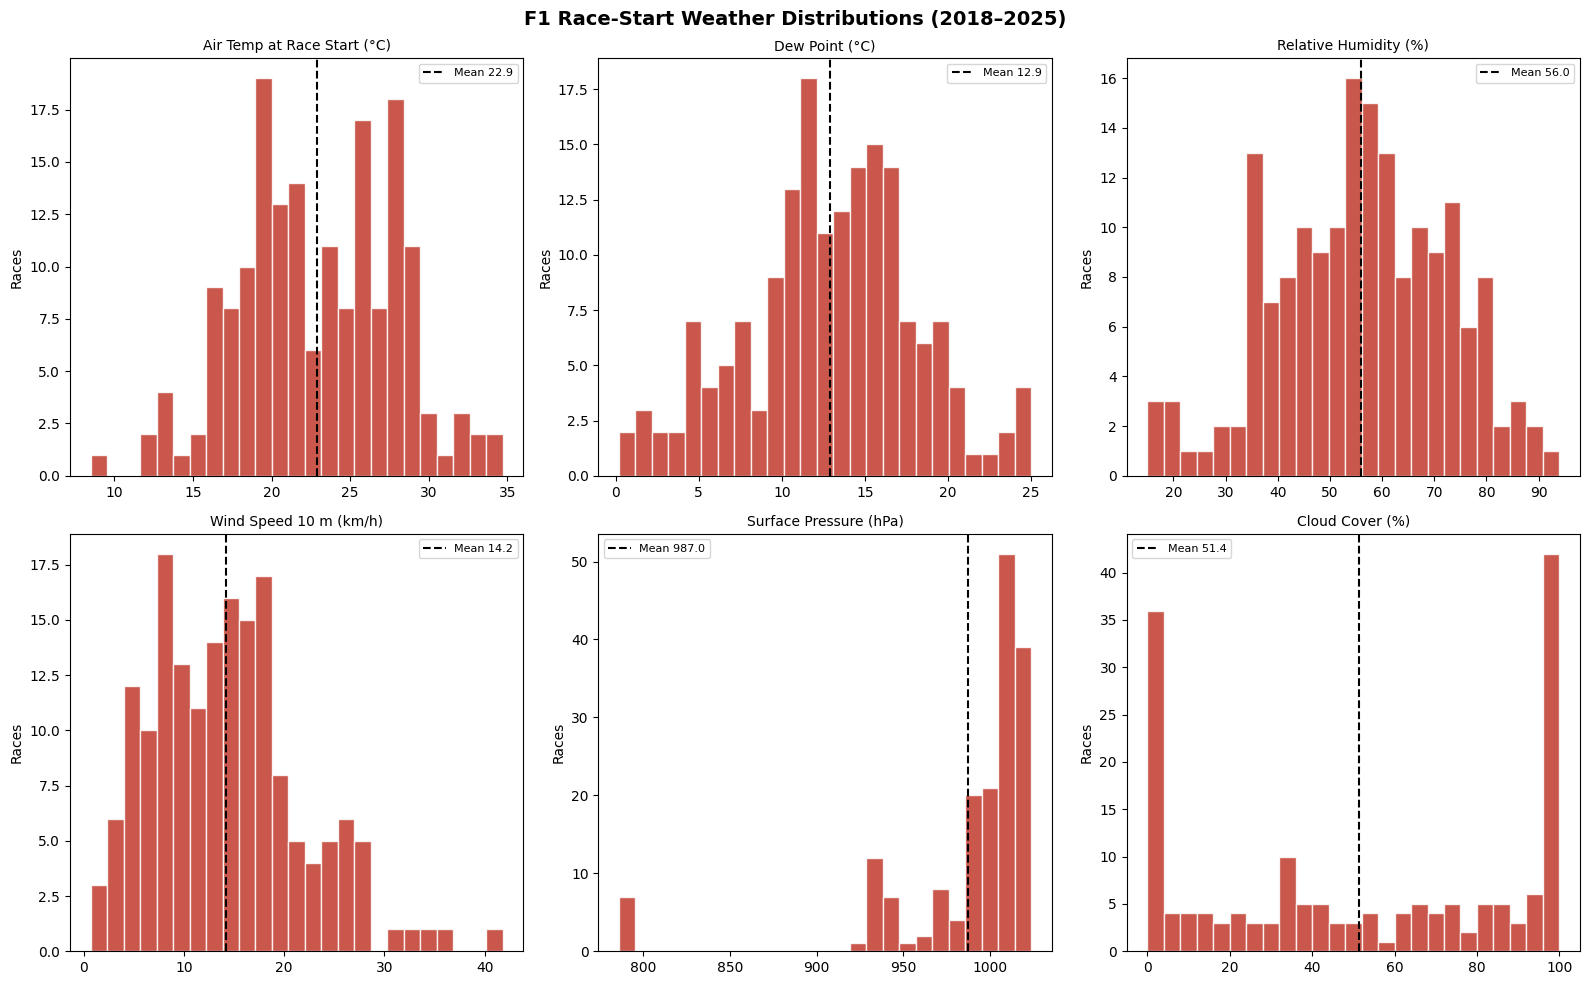

In [17]:
# ── Figure: Key weather distributions ──────────────────────────────────────
# Prefer dew_point over soil_temperature_0cm (not available from this archive)
plot_vars_candidates = [
    ("temperature_2m",      "Air Temp at Race Start (°C)"),
    ("dew_point_2m",        "Dew Point (°C)"),
    ("relative_humidity_2m","Relative Humidity (%)"),
    ("wind_speed_10m",      "Wind Speed 10 m (km/h)"),
    ("surface_pressure",    "Surface Pressure (hPa)"),
    ("cloud_cover",         "Cloud Cover (%)"),
]
# Only include panels where data exists
plot_vars = [(col, lbl) for col, lbl in plot_vars_candidates
             if col in df.columns and df[col].notna().any()]

n = len(plot_vars)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
fig.suptitle("F1 Race-Start Weather Distributions (2018–2025)", fontsize=14, fontweight="bold")
axes_flat = axes.flat if n > 1 else [axes]

for ax, (col, label) in zip(axes_flat, plot_vars):
    data = df[col].dropna()
    ax.hist(data, bins=25, edgecolor="white", color="#c0392b", alpha=0.85)
    ax.axvline(data.mean(), color="black", linewidth=1.5, linestyle="--",
               label=f"Mean {data.mean():.1f}")
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel("Races")

# Hide any unused axes
for ax in list(axes_flat)[n:]:
    ax.set_visible(False)

plt.tight_layout()
# plt.savefig("weather_distributions.png", dpi=150)
plt.show()


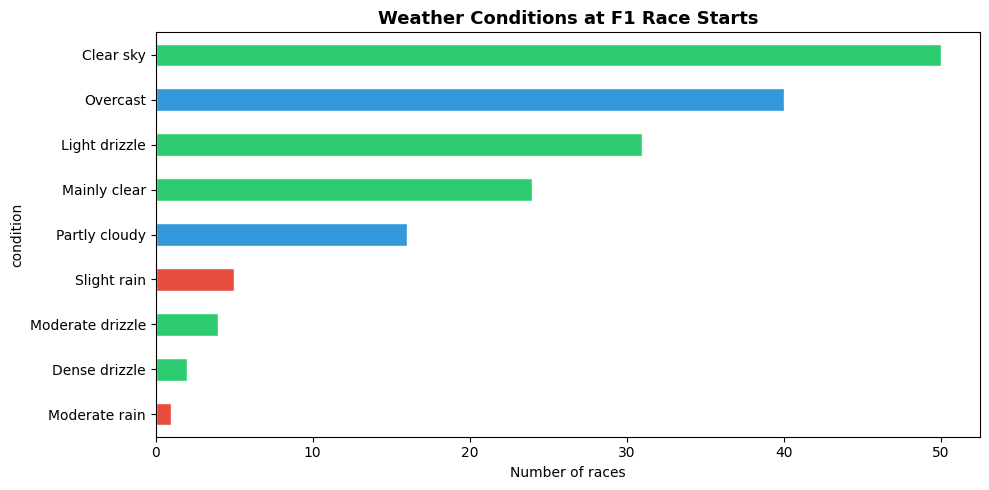

In [18]:
# ── Figure: WMO Condition breakdown ────────────────────────────────────────
cond_counts = df["condition"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c" if "rain" in c.lower() or "shower" in c.lower() or "thunder" in c.lower()
          else "#3498db" if "cloud" in c.lower() or "overcast" in c.lower()
          else "#2ecc71"
          for c in cond_counts.index]

cond_counts.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("Weather Conditions at F1 Race Starts", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of races")
ax.invert_yaxis()
plt.tight_layout()
# plt.savefig("weather_conditions.png", dpi=150)
plt.show()